# Mall Customer Segmentation Data Analysis

## Set Up

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as scikit_learn

## Data Loading & Preprocessing

In [3]:
mall_customers = pd.read_csv("../data/Mall_Customers.csv")

In [4]:
mall_customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
mall_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
mall_customers.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
null_counts = mall_customers.isnull().sum()
print("Null values in each column:")
print(null_counts)

Null values in each column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [8]:
duplicate_counts = mall_customers.duplicated().sum()
print("Number of duplicate rows:", duplicate_counts)

Number of duplicate rows: 0


In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
mall_customers['Gender'] = label_encoder.fit_transform(mall_customers['Gender'])
mall_customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [10]:
mall_customers.rename(columns={'Annual Income (k$)': 'Annual_Income_k$', 'Spending Score (1-100)': 'Spending_Score'}, inplace=True)
mall_customers.head()

,CustomerID,Gender,Age,Annual_Income_k$,Spending_Score
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


## Finding Optimal K with Elbow Method

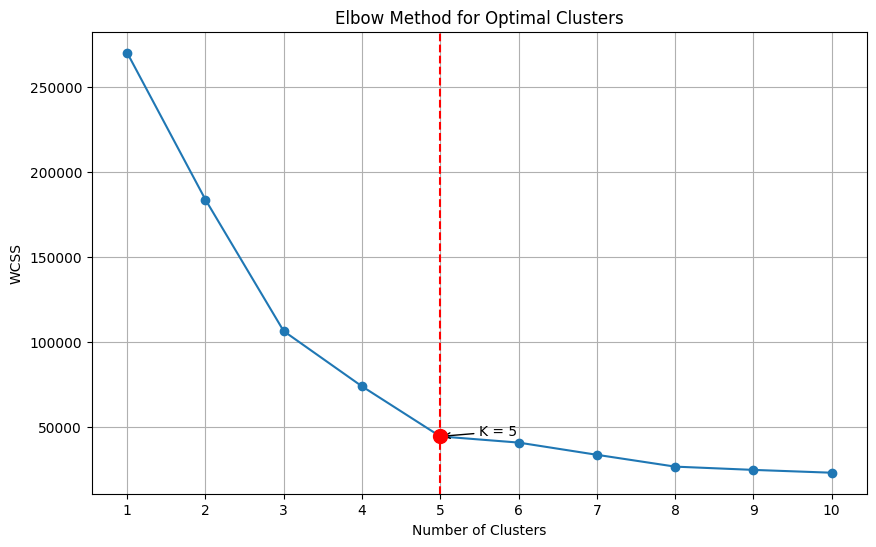

In [11]:
from sklearn.cluster import KMeans

features = mall_customers[['Annual_Income_k$', 'Spending_Score']]
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize = (10, 6))
plt.plot(range(1, 11), wcss, marker='o')

optimal_k = 5
optimal_wcss = wcss[optimal_k - 1]

plt.axvline(
    x = optimal_k,
    color = "red",
    linestyle = "--",
    label = f"Optimal K = {optimal_k}"
)

plt.scatter(
    optimal_k,
    optimal_wcss,
    s = 100,
    color = "red",
    zorder = 5
)

plt.annotate(
    f"K = {optimal_k}",
    xy = (optimal_k, optimal_wcss),
    xytext = (optimal_k + 0.5, optimal_wcss + 500),
    arrowprops = dict(arrowstyle="->")
)

plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid()
plt.show()

**Insight:** By graphing the Within-Cluster Sum of Squares (WCSS) against the number of clusters, we can clearly see the 'elbow' point. The WCSS drops drastically at first, but right at $K=5$, the rate of decrease slows down and the line flattens out. This tells us mathematically that 5 is the optimal number of clusters for this dataset—adding any more clusters wouldn't give us enough additional variance explanation to justify making the model more complex.

## KMeans Clustering + Visualization

### Scatter 1: Annual Income vs Spending Score — colored by cluster

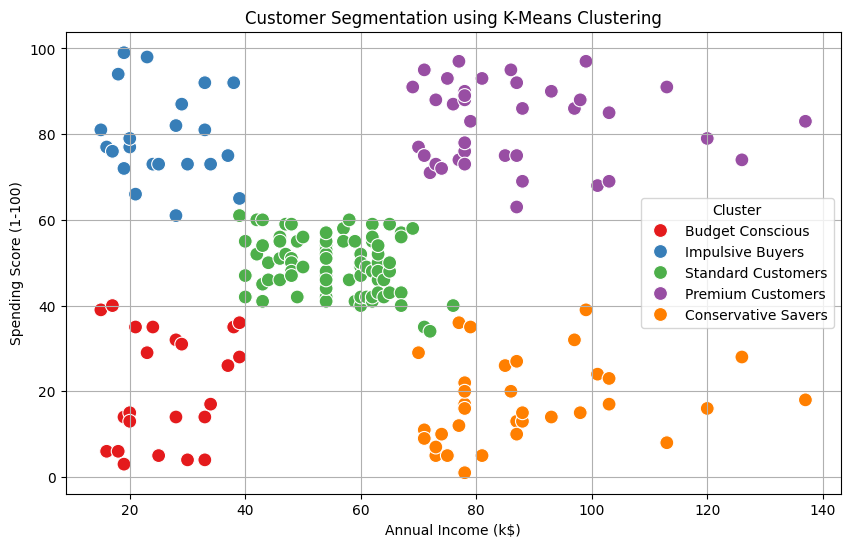

In [15]:
kmeans = KMeans(n_clusters = optimal_k, random_state = 42)
mall_customers['Cluster'] = kmeans.fit_predict(features)
cluster_labels = {
    0: 'Standard Customers',
    1: 'Premium Customers',
    2: 'Impulsive Buyers',
    3: 'Conservative Savers',
    4: 'Budget Conscious',
}
plt.figure(figsize = (10, 6))
mall_customers['Cluster Name'] = mall_customers['Cluster'].map(cluster_labels)
sns.scatterplot(
    data = mall_customers,
    x = 'Annual_Income_k$',
    y = 'Spending_Score',
    hue = 'Cluster Name',
    palette = 'Set1',
    s = 100
)
plt.title('Customer Segmentation using K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title = 'Cluster')
plt.grid()
plt.savefig("../outputs/customer_segmentation.png")
plt.show()

**Insight:** This scatter plot gives us our most actionable buyer personas. The most interesting groups are on the right side: the Premium Customers (purple) and Conservative Savers (orange). Both groups have high annual incomes (above 70k), but completely opposite spending behaviors. We also have a highly actionable group in the top left—the Impulsive Buyers (blue)—who have low income but spend heavily, making them ideal targets for low-ticket, high-appeal marketing campaigns.

### Scatter 2: Age vs Spending Score — colored by cluster

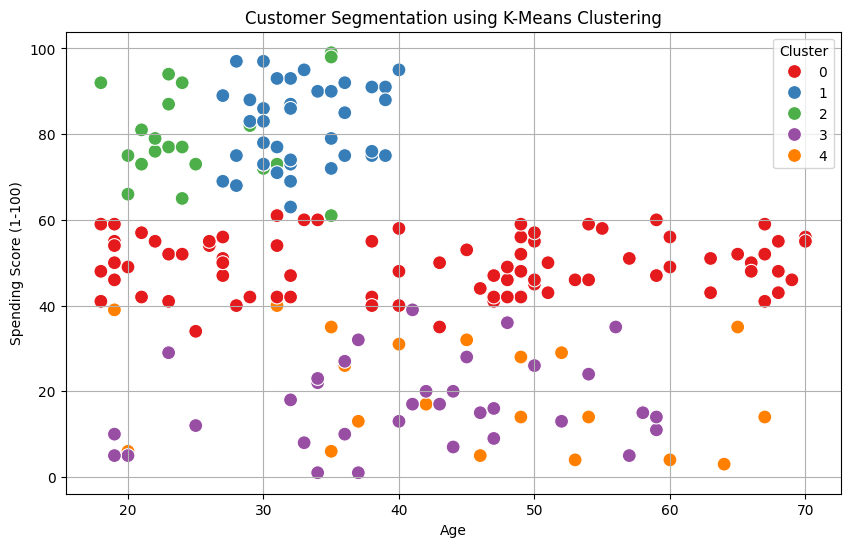

In [13]:
plt.figure(figsize = (10, 6))
sns.scatterplot(
    data = mall_customers,
    x = 'Age',
    y = 'Spending_Score',
    hue = 'Cluster',
    palette = 'Set1',
    s = 100
)
plt.title('Customer Segmentation using K-Means Clustering')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend(title = 'Cluster')
plt.grid()
plt.show()

**Insight:** The biggest takeaway here is the strict age ceiling for high spenders. If you look closely, absolutely zero customers over the age of 40 have a spending score higher than 60. The high-spending clusters (Clusters 1 and 2, the blue and green dots) are exclusively made up of younger demographics, roughly between ages 18 and 40. This means any premium or high-cost marketing efforts should strictly target the under-40 crowd.

### Bar chart: Cluster size — how many customers in each segment

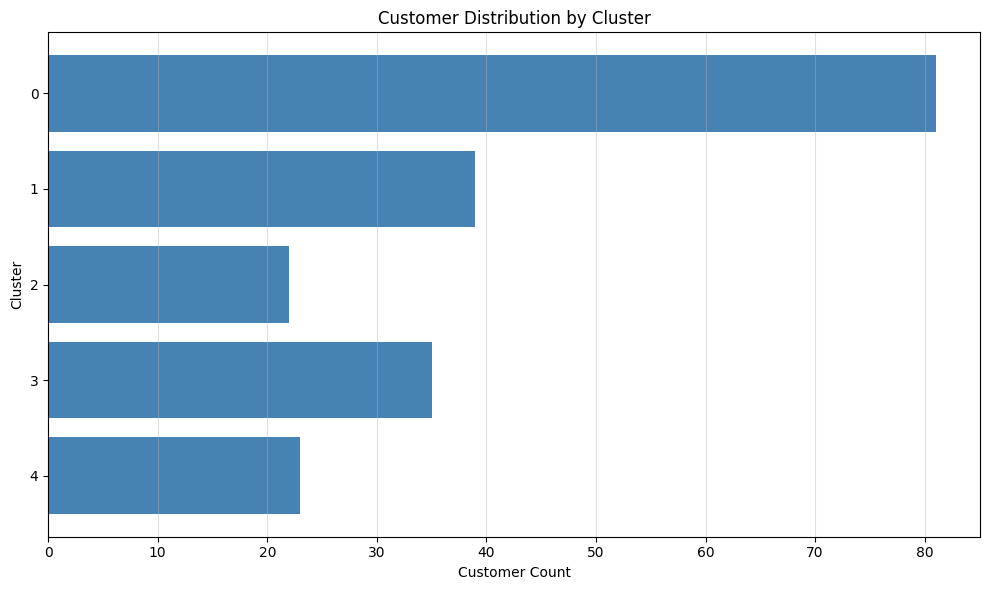

In [14]:
mall_customers
cluster_count = (
    mall_customers
    .groupby('Cluster')['CustomerID']
    .count()
    .reset_index(name='Customer_Count')
    .sort_values(by='Customer_Count', ascending=False)
)
plt.figure(figsize=(10, 6))
plt.barh(cluster_count["Cluster"], cluster_count["Customer_Count"], color='steelblue')
plt.grid(axis='x', alpha=0.4)
plt.xlabel("Customer Count")
plt.ylabel("Cluster")
plt.title("Customer Distribution by Cluster")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/customer_distribution_by_cluster.png", dpi=150)
plt.show()

**Insight:** While the scatter plots highlight extreme spending behaviors, this bar chart brings us back to reality by showing our actual customer volume. Cluster 0 is by far our largest segment, with over 80 customers, dominating the overall distribution. Looking back at the previous charts, we know these are generally our average or lower-spending users. This means that while our 'Premium' customers are valuable, our baseline revenue relies heavily on a massive volume of everyday, budget-conscious consumers.

## Key Business Takeaways

**Age is the Ultimate Spending Barrier:** The most glaring trend from our model is that high-volume spending completely drops off after age 40. Regardless of their annual income, the older demographics in this dataset are strictly conservative with their spending. All premium and high-ticket marketing campaigns must aggressively target the 18–39 age bracket to maximize return on ad spend.

**Two Distinct "High-Value" Strategies:** The data revealed two major high-spending segments that require completely different engagement tactics. The Premium Customers (high income, high spend) will respond best to VIP loyalty programs and exclusive luxury branding. In contrast, the Impulsive Buyers (low income, high spend) are likely driven by trends and FOMO, making them the perfect target audience for flash sales, limited-time offers, and social media campaigns.

**Volume vs. Value:** While it is tempting to focus marketing efforts exclusively on the highest spenders, our largest cluster by far consists of average-income, average-spending users. This group is the foundation of our baseline revenue. We need to ensure broad, everyday retention strategies—like bundle deals or basic point-reward systems—are in place to keep this massive volume of users from churning to competitors.

**Pivoting the Messaging for Older Demographics:** Since customers over 40 fall almost entirely into the low-spending or conservative saver categories, pitching them expensive or flashy products is highly inefficient. Any marketing directed at this older segment should pivot entirely away from "luxury" and focus heavily on messaging centered around value, durability, and practical utility.